# This notebook samples images from HaGRID, extracts MediaPipe hand landmarks,
# and generates hand_landmarks.csv used for model training.

##### Copyright 2023 The MediaPipe Authors. All Rights Reserved.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Hand Landmarks Detection with MediaPipe Tasks

This notebook shows you how to use MediaPipe Tasks Python API to detect hand landmarks from images.

## Preparation

Let's start with installing MediaPipe.

In [2]:
!pip install -q mediapipe

Then download an off-the-shelf model bundle. Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/hand_landmarker#models) for more information about this model bundle.

In [3]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

## Visualization utilities

In [4]:
#@markdown We implemented some functions to visualize the hand landmark detection results. <br/> Run the following cell to activate the functions.
import mediapipe as mp
import numpy as np

mp_hands = mp.tasks.vision.HandLandmarksConnections
mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

MARGIN = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
HANDEDNESS_TEXT_COLOR = (88, 205, 54) # vibrant green

def draw_landmarks_on_image(rgb_image, detection_result):
  hand_landmarks_list = detection_result.hand_landmarks
  handedness_list = detection_result.handedness
  annotated_image = np.copy(rgb_image)

  # Loop through the detected hands to visualize.
  for idx in range(len(hand_landmarks_list)):
    hand_landmarks = hand_landmarks_list[idx]
    handedness = handedness_list[idx]

    # Draw the hand landmarks.
    mp_drawing.draw_landmarks(
      annotated_image,
      hand_landmarks,
      mp_hands.HAND_CONNECTIONS,
      mp_drawing_styles.get_default_hand_landmarks_style(),
      mp_drawing_styles.get_default_hand_connections_style())

    # Get the top left corner of the detected hand's bounding box.
    height, width, _ = annotated_image.shape
    x_coordinates = [landmark.x for landmark in hand_landmarks]
    y_coordinates = [landmark.y for landmark in hand_landmarks]
    text_x = int(min(x_coordinates) * width)
    text_y = int(min(y_coordinates) * height) - MARGIN

    # Draw handedness (left or right hand) on the image.
    cv2.putText(annotated_image, f"{handedness[0].category_name}",
                (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX,
                FONT_SIZE, HANDEDNESS_TEXT_COLOR, FONT_THICKNESS, cv2.LINE_AA)

  return annotated_image

## Download test image

Let's grab a test image that we'll use later. The image is from [Unsplash](https://unsplash.com/photos/mt2fyrdXxzk).

In [5]:
import os
import random
import shutil

random.seed(42)

source_root = "/Users/oviyamurali/Downloads"          # contains like/ and dislike/
target_root = "sampled_hagrid"

classes = ["like", "dislike", "ok", "stop", "point", "peace", "fist", "hand_heart"]
num_images_per_class = 5000

for class_name in classes:
    src_dir = os.path.join(source_root, class_name)
    dst_dir = os.path.join(target_root, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    images = [
        f for f in os.listdir(src_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    sampled = random.sample(images, min(num_images_per_class, len(images)))

    for img_name in sampled:
        shutil.copy(
            os.path.join(src_dir, img_name),
            os.path.join(dst_dir, img_name)
        )

    print(class_name, "copied:", len(sampled))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/oviyamurali/Downloads/like'

sampled_hagrid/peace/ea7e24e7-93d3-43e1-a78a-f9a52329232a.jpg


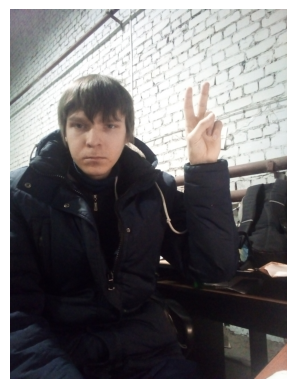

In [6]:
import os
import cv2
import matplotlib.pyplot as plt

folder = "sampled_hagrid/peace"

image_name = os.listdir(folder)[1000]

image_path = os.path.join(folder, image_name)

print(image_path)

img = cv2.imread(image_path)

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

Optionally, you can upload your own image. If you want to do so, uncomment and run the cell below.

## Running inference and visualizing the results

Here are the steps to run hand landmark detection using MediaPipe.

Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/hand_landmarker/python) to learn more about configuration options that this solution supports.


I0000 00:00:1779849102.872376 4634817 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 8, prefix = pthread-default
I0000 00:00:1779849102.914647 4634817 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M3
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779849102.918301 4634819 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779849102.921294 4634820 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779849102.962649 4634821 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


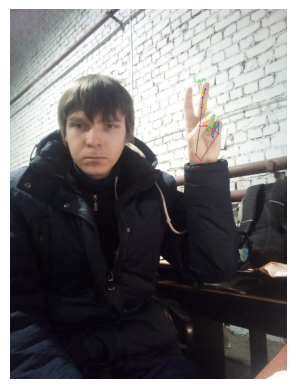

In [7]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an HandLandmarker object.
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options,
                                       num_hands=2)
detector = vision.HandLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file(image_path)

# STEP 4: Detect hand landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the classification result. In this case, visualize it.
# annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
# cv2_imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
rgb_image = image.numpy_view()

# draw_landmarks_on_image expects BGR
bgr_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR)

annotated_image = draw_landmarks_on_image(bgr_image, detection_result)

# matplotlib expects RGB
annotated_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

plt.imshow(annotated_rgb)
plt.axis("off")
plt.show()

In [8]:
print(len(detection_result.hand_landmarks))

row = []
for hand_landmarks in detection_result.hand_landmarks: 
    for landmark in hand_landmarks:
            print(f"X: {landmark.x}, Y: {landmark.y}, Z: {landmark.z}")
            row.append(landmark.x)
            row.append(landmark.y)
            row.append(landmark.z)


1
X: 0.6883946061134338, Y: 0.4089731276035309, Z: -1.0726820676154603e-07
X: 0.670248806476593, Y: 0.3924885392189026, Z: -0.036233969032764435
X: 0.6654098629951477, Y: 0.3482182025909424, Z: -0.046644750982522964
X: 0.6897215247154236, Y: 0.3125975430011749, Z: -0.05295518413186073
X: 0.7210900783538818, Y: 0.29435715079307556, Z: -0.05826130881905556
X: 0.6855932474136353, Y: 0.3166654407978058, Z: -0.016604451462626457
X: 0.692435085773468, Y: 0.2663447856903076, Z: -0.019428620114922523
X: 0.6965755820274353, Y: 0.23907437920570374, Z: -0.019521428272128105
X: 0.7054290771484375, Y: 0.21714648604393005, Z: -0.02310798689723015
X: 0.7097569704055786, Y: 0.31600117683410645, Z: -0.005929755978286266
X: 0.7035546898841858, Y: 0.264414519071579, Z: -0.017267826944589615
X: 0.6950298547744751, Y: 0.23268458247184753, Z: -0.026186401024460793
X: 0.6910074353218079, Y: 0.20306909084320068, Z: -0.032175738364458084
X: 0.7298179864883423, Y: 0.3238535225391388, Z: 0.0007913309382274747
X:

In [11]:
# Update this path to the location of your local HaGRID dataset
source_root = "/Users/oviyamurali/Downloads/sampled_hagrid"


classes = ["like", "dislike", "ok", "stop", "point", "peace", "fist", "hand_heart"]

x = []
y = []
for label in classes:

    folder = os.path.join(source_root, label)

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        try:
            # STEP 3: Load the input image.
            image = mp.Image.create_from_file(image_path)
            
            # STEP 4: Detect hand landmarks from the input image.
            detection_result = detector.detect(image)
            # hand_landmarks = detection_result.hand_landmarks[0]
            # hand_landmarks = hand_landmarks[0]
    
            if detection_result.hand_landmarks:
                hand_landmarks = detection_result.hand_landmarks[0]

                wrist = hand_landmarks[0]
                
                features = []
                # Your extraction code here
                for landmark in hand_landmarks:
                    features.extend([
                        landmark.x - wrist.x,
                        landmark.y - wrist.y,
                        landmark.z - wrist.z
                    ])
            else:
                # print("No hands detected in the image.")
                hand_landmarks = None
                features = []
                
        except Exception as e:
            print("Error:", image_path, e)
            X.append([np.nan] * 63)
            y.append(label)

        
        # print(len(features))
        
        y.append(label)
        x.append(features)       

E0000 00:00:1779859668.169301 4634818 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-26T22:36:48.133398-07:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1779859728.175252 4634818 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-26T22:36:48.133398-07:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1779859788.181371 4634818 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-26T22:36:48.133398-07:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1779859848.187483 4634818 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid

In [17]:
import pandas as pd

landmark_names = [
    "wrist",

    "thumb_cmc",
    "thumb_mcp",
    "thumb_ip",
    "thumb_tip",

    "index_mcp",
    "index_pip",
    "index_dip",
    "index_tip",

    "middle_mcp",
    "middle_pip",
    "middle_dip",
    "middle_tip",

    "ring_mcp",
    "ring_pip",
    "ring_dip",
    "ring_tip",

    "pinky_mcp",
    "pinky_pip",
    "pinky_dip",
    "pinky_tip",
    
]

columns = []

for name in landmark_names:
    columns.extend([
        f"{name}_x",
        f"{name}_y",
        f"{name}_z"
    ])



df = pd.DataFrame(x, columns=columns)

# df.columns = landmark_names
df["label"] = y
df.isna().sum()
df.isna().groupby(df['label']).sum()
df


,wrist_x,wrist_y,wrist_z,thumb_cmc_x,thumb_cmc_y,thumb_cmc_z,thumb_mcp_x,thumb_mcp_y,thumb_mcp_z,thumb_ip_x,...,pinky_pip_x,pinky_pip_y,pinky_pip_z,pinky_dip_x,pinky_dip_y,pinky_dip_z,pinky_tip_x,pinky_tip_y,pinky_tip_z,label
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,like
1,0.0,0.0,0.0,0.022776,-0.028277,-0.004338,0.045576,-0.048785,-0.012837,0.063784,...,0.107724,0.018118,-0.012471,0.106300,0.012117,-0.006140,0.098089,0.009252,-0.001128,like
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,like
3,0.0,0.0,0.0,-0.037863,-0.109196,-0.002503,-0.102102,-0.217803,-0.019851,-0.154821,...,-0.316926,0.052474,-0.098607,-0.264260,0.058219,-0.080353,-0.213860,0.050064,-0.066235,like
4,0.0,0.0,0.0,-0.012407,-0.056363,0.008407,-0.032338,-0.098374,0.012692,-0.057355,...,-0.088238,0.033232,0.020512,-0.073565,0.032139,0.026240,-0.060905,0.024735,0.028535,like
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0.0,0.0,0.0,0.039021,-0.004344,-0.002307,0.077283,-0.019625,-0.008901,0.110459,...,0.020190,-0.096079,-0.052485,0.028134,-0.116776,-0.056367,0.039559,-0.134874,-0.058945,hand_heart
39996,0.0,0.0,0.0,0.016478,-0.001631,-0.001122,0.032080,-0.008857,-0.002578,0.043534,...,0.016647,-0.082713,-0.018552,0.020814,-0.098688,-0.020651,0.025193,-0.112701,-0.022121,hand_heart
39997,0.0,0.0,0.0,0.032486,-0.000761,-0.009575,0.058102,-0.007129,-0.020307,0.081696,...,0.000342,-0.053092,-0.066437,0.004648,-0.065206,-0.075193,0.011553,-0.075433,-0.081374,hand_heart
39998,0.0,0.0,0.0,-0.034225,-0.000819,-0.014668,-0.069026,-0.005140,-0.029260,-0.097810,...,-0.018641,-0.078153,-0.041447,-0.033979,-0.084665,-0.045458,-0.053680,-0.083926,-0.048132,hand_heart


In [ ]:
3194-40000

In [20]:
# # df = df.dropna()
# df["label"].value_counts()
df.to_csv("hand_landmarks.csv", index=False)